In [1]:
import os, time, random
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('Devices:', tf.config.list_physical_devices())

TensorFlow: 2.21.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Training images: 20,000 | image shape: (32, 32, 3) | range: [-1.0, 1.0]


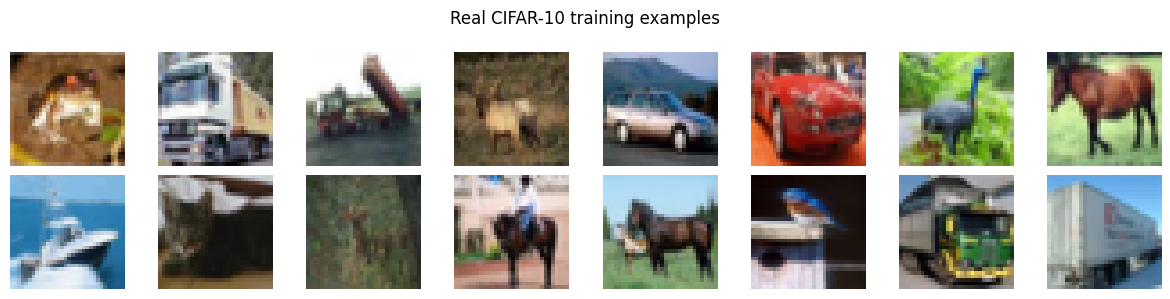

In [3]:
(x_train, _), (_, _) = keras.datasets.cifar10.load_data()
# Use a deterministic subset for a manageable classroom run. Scale pixels to [-1, 1].
TRAIN_LIMIT = 20000
x_train = (x_train[:TRAIN_LIMIT].astype('float32') - 127.5) / 127.5
BATCH = 64
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(TRAIN_LIMIT, seed=SEED, reshuffle_each_iteration=True).batch(BATCH, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
print(f'Training images: {len(x_train):,} | image shape: {x_train.shape[1:]} | range: [{x_train.min():.1f}, {x_train.max():.1f}]')
fig, ax = plt.subplots(2, 8, figsize=(12, 3))
for a, im in zip(ax.flat, x_train[:16]): a.imshow((im + 1) / 2); a.axis('off')
fig.suptitle('Real CIFAR-10 training examples'); plt.tight_layout(); plt.show()

In [4]:
Z_DIM = W_DIM = 128
CHANNELS = {4: 128, 8: 128, 16: 64, 32: 32}

class MappingNetwork(keras.Model):
    def __init__(self):
        super().__init__()
        self.blocks = [layers.Dense(W_DIM, kernel_initializer='he_normal') for _ in range(8)]
    def call(self, z):
        z = z * tf.math.rsqrt(tf.reduce_mean(tf.square(z), axis=1, keepdims=True) + 1e-8)
        for dense in self.blocks: z = tf.nn.leaky_relu(dense(z), alpha=0.2)
        return z

class AdaIN(layers.Layer):
    def __init__(self, channels):
        super().__init__(); self.channels = channels
        self.norm = layers.LayerNormalization(axis=[1, 2], center=False, scale=False)
        self.affine = layers.Dense(2 * channels, kernel_initializer='zeros', bias_initializer='zeros')
    def call(self, x, w):
        scale, bias = tf.split(self.affine(w), 2, axis=-1)
        return self.norm(x) * (1.0 + scale[:, None, None, :]) + bias[:, None, None, :]

class StyledConv(layers.Layer):
    def __init__(self, channels):
        super().__init__(); self.conv = layers.Conv2D(channels, 3, padding='same'); self.adain = AdaIN(channels)
    def build(self, shapes):
        self.noise_strength = self.add_weight(name='noise_strength', shape=(), initializer='zeros', trainable=True)
    def call(self, x, w, noise=None):
        x = self.conv(x)
        if noise is None: noise = tf.random.normal([tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], 1])
        x = x + self.noise_strength * noise
        return tf.nn.leaky_relu(self.adain(x, w), alpha=0.2)

class StyleGenerator(keras.Model):
    def __init__(self):
        super().__init__(); self.mapping = MappingNetwork()
        self.constant = self.add_weight(name='learned_constant', shape=(1, 4, 4, CHANNELS[4]), initializer='random_normal', trainable=True)
        self.convs = [StyledConv(CHANNELS[r]) for r in (4,4,8,8,16,16,32,32)]
        self.to_rgb = layers.Conv2D(3, 1, padding='same', activation='tanh')
    def call(self, inputs, training=False, return_styles=False):
        z, styles = inputs if isinstance(inputs, (tuple, list)) else (inputs, None)
        if styles is None: styles = tf.repeat(self.mapping(z)[:, None, :], 8, axis=1)
        x = tf.repeat(self.constant, tf.shape(z)[0], axis=0)
        for i, conv in enumerate(self.convs):
            if i in (2, 4, 6): x = tf.image.resize(x, [tf.shape(x)[1]*2, tf.shape(x)[2]*2], method='nearest')
            x = conv(x, styles[:, i, :])
        image = self.to_rgb(x)
        return (image, styles) if return_styles else image

class Discriminator(keras.Model):
    def __init__(self):
        super().__init__(); self.blocks = []
        for c in (32, 64, 128, 128):
            self.blocks.append(keras.Sequential([layers.Conv2D(c, 4, strides=2, padding='same'), layers.LeakyReLU(negative_slope=0.2)]))
        self.head = keras.Sequential([layers.Flatten(), layers.Dense(1)])
    def call(self, x, training=False):
        for block in self.blocks: x = block(x, training=training)
        return self.head(x)

G, D = StyleGenerator(), Discriminator()
_ = G(tf.zeros([1, Z_DIM])); _ = D(tf.zeros([1, 32, 32, 3]))
print(f'Generator parameters: {G.count_params():,} | discriminator: {D.count_params():,}')

Generator parameters: 1,044,651 | discriminator: 428,385


In [5]:
EPOCHS = 10
g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.0, beta_2=0.99)
d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.0, beta_2=0.99)
fixed_z = tf.random.normal([64, Z_DIM], seed=SEED)
g_loss_history, d_loss_history = [], []

@tf.function
def train_step(real):
    batch = tf.shape(real)[0]
    z = tf.random.normal([batch, Z_DIM])
    with tf.GradientTape() as dt:
        fake = tf.stop_gradient(G(z, training=True))
        real_logits, fake_logits = D(real, training=True), D(fake, training=True)
        d_loss = tf.reduce_mean(tf.nn.softplus(-real_logits)) + tf.reduce_mean(tf.nn.softplus(fake_logits))
    d_grads = dt.gradient(d_loss, D.trainable_variables); d_optimizer.apply_gradients(zip(d_grads, D.trainable_variables))
    with tf.GradientTape() as gt:
        fake = G(z, training=True); fake_logits = D(fake, training=True)
        g_loss = tf.reduce_mean(tf.nn.softplus(-fake_logits))
    g_grads = gt.gradient(g_loss, G.trainable_variables); g_optimizer.apply_gradients(zip(g_grads, G.trainable_variables))
    return d_loss, g_loss

start = time.time()
for epoch in range(1, EPOCHS + 1):
    d_avg, g_avg, batches = 0.0, 0.0, 0
    for real in dataset:
        dl, gl = train_step(real); d_avg += float(dl); g_avg += float(gl); batches += 1
    d_loss_history.append(d_avg / batches); g_loss_history.append(g_avg / batches)
    print(f'Epoch {epoch:02d}/{EPOCHS} | D {d_loss_history[-1]:.3f} | G {g_loss_history[-1]:.3f} | {time.time()-start:.0f}s elapsed')

Epoch 01/10 | D 1.398 | G 0.708 | 25s elapsed
Epoch 02/10 | D 1.388 | G 0.696 | 37s elapsed
Epoch 03/10 | D 1.387 | G 0.694 | 52s elapsed
Epoch 04/10 | D 1.387 | G 0.694 | 63s elapsed
Epoch 05/10 | D 1.386 | G 0.693 | 75s elapsed
Epoch 06/10 | D 1.386 | G 0.693 | 87s elapsed
Epoch 07/10 | D 1.386 | G 0.693 | 98s elapsed
Epoch 08/10 | D 1.386 | G 0.693 | 110s elapsed
Epoch 09/10 | D 1.386 | G 0.693 | 122s elapsed
Epoch 10/10 | D 1.386 | G 0.693 | 133s elapsed


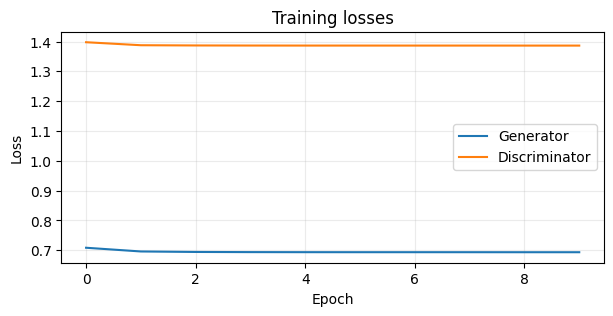

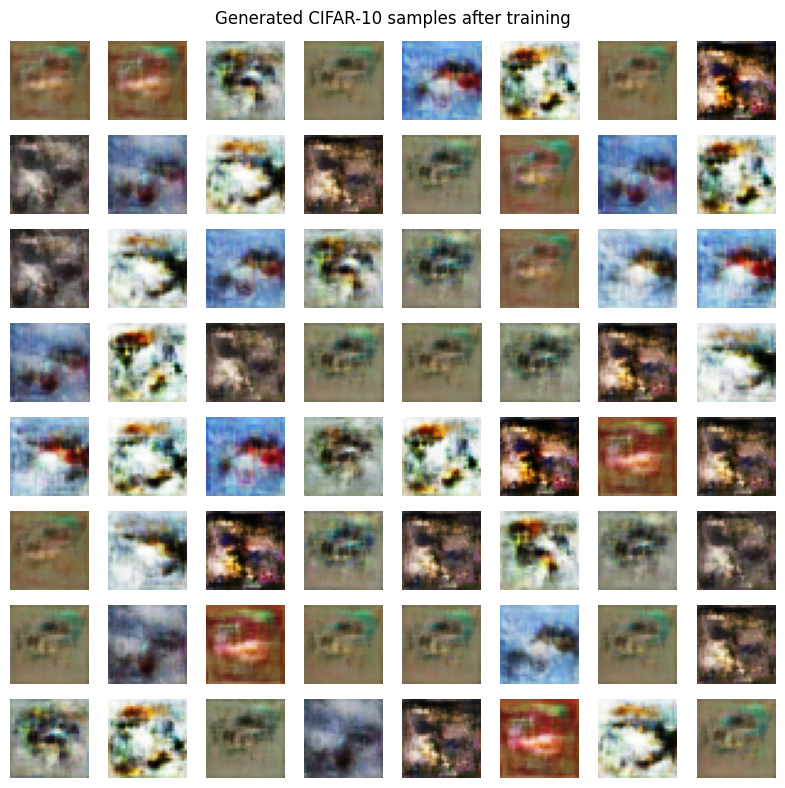

In [6]:
def show_grid(images, title, nrow=8, figsize=(8, 8)):
    images = (images.numpy() + 1) / 2
    fig, axes = plt.subplots(int(np.ceil(len(images)/nrow)), nrow, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, im in zip(axes, images): ax.imshow(np.clip(im, 0, 1)); ax.axis('off')
    for ax in axes[len(images):]: ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3)); plt.plot(g_loss_history, label='Generator'); plt.plot(d_loss_history, label='Discriminator'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Training losses'); plt.grid(alpha=.25); plt.show()
show_grid(G(fixed_z, training=False), 'Generated CIFAR-10 samples after training', figsize=(8,8))

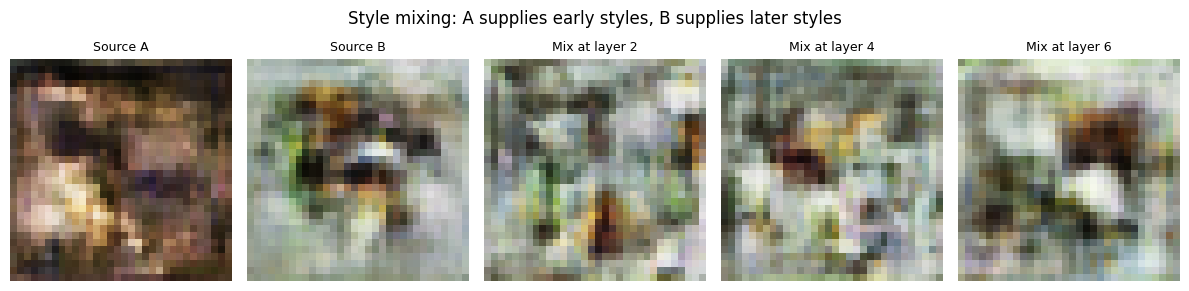

In [7]:
# Early synthesis styles control coarse structure; later styles influence finer appearance.
z_a, z_b = tf.random.normal([1,Z_DIM]), tf.random.normal([1,Z_DIM])
w_a, w_b = G.mapping(z_a), G.mapping(z_b)
images = [G(z_a), G(z_b)]
labels = ['Source A', 'Source B']
for cutoff in (2, 4, 6):
    ws = tf.concat([tf.repeat(w_a[:,None,:], cutoff, axis=1), tf.repeat(w_b[:,None,:], 8-cutoff, axis=1)], axis=1)
    images.append(G((z_a, ws))); labels.append(f'Mix at layer {cutoff}')
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, im, label in zip(axes, images, labels): ax.imshow((im[0].numpy()+1)/2); ax.set_title(label, fontsize=9); ax.axis('off')
fig.suptitle('Style mixing: A supplies early styles, B supplies later styles'); plt.tight_layout(); plt.show()

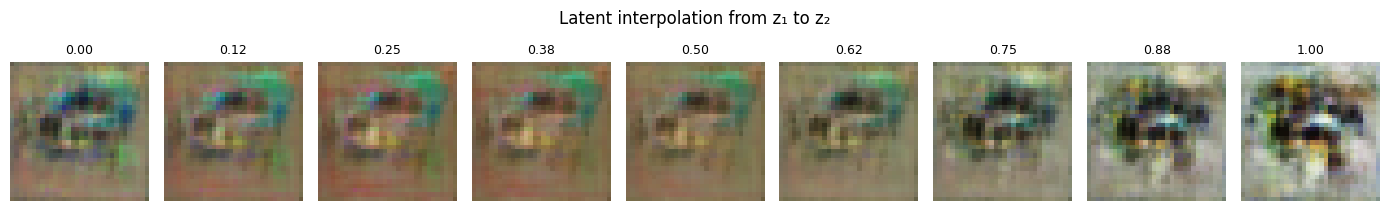

In [8]:
z1, z2 = tf.random.normal([1,Z_DIM]), tf.random.normal([1,Z_DIM])
t = tf.linspace(0., 1., 9)[:,None]
z_path = (1-t)*z1 + t*z2
path = G(z_path, training=False)
fig, axes = plt.subplots(1, 9, figsize=(14,2.2))
for i, (ax, im) in enumerate(zip(axes, path)): ax.imshow((im.numpy()+1)/2); ax.set_title(f'{i/8:.2f}', fontsize=9); ax.axis('off')
fig.suptitle('Latent interpolation from z₁ to z₂'); plt.tight_layout(); plt.show()